# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [5]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun

In [6]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [7]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [ ]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [9]:
data

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6805395,10777,-1,27,15,23,0.000210,-1,0.093303,0
6805396,10777,-1,27,21,23,0.000190,-1,0.087002,0
6805397,10777,-1,27,23,9,0.000216,-1,0.069199,0
6805398,10777,-1,27,24,9,0.000611,-1,0.083242,0


### Get the deconv data (share the energy)

In [ ]:
datadeco   = evtfun.get_deconvoluted_data(data)
evtfun.test_get_deconvoluted_data(datadeco)
datadeco = datadeco[datadeco.decopred == 1].copy()

## Display an event

In [17]:
ievent   = 22

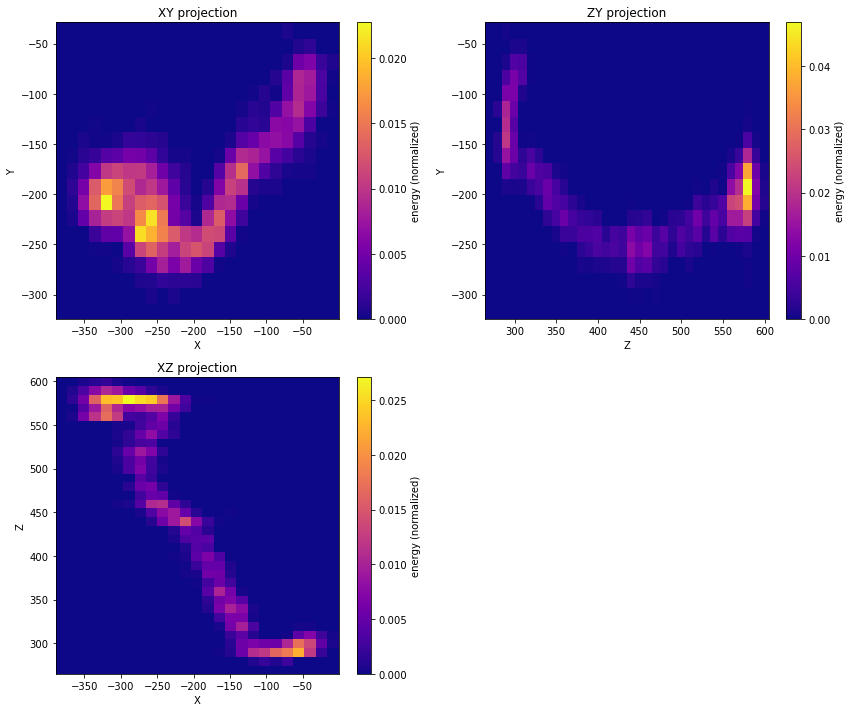

In [67]:
evt   = data.groupby('dataset_id').get_group(ievent)
coors = evtfun.get_coors(evt, bin_info)
bins  = evtfun.get_bins(coors, bin_widths)
ene   = evt.energy.values 
evtfun.event_display(coors, bins, ene = ene);


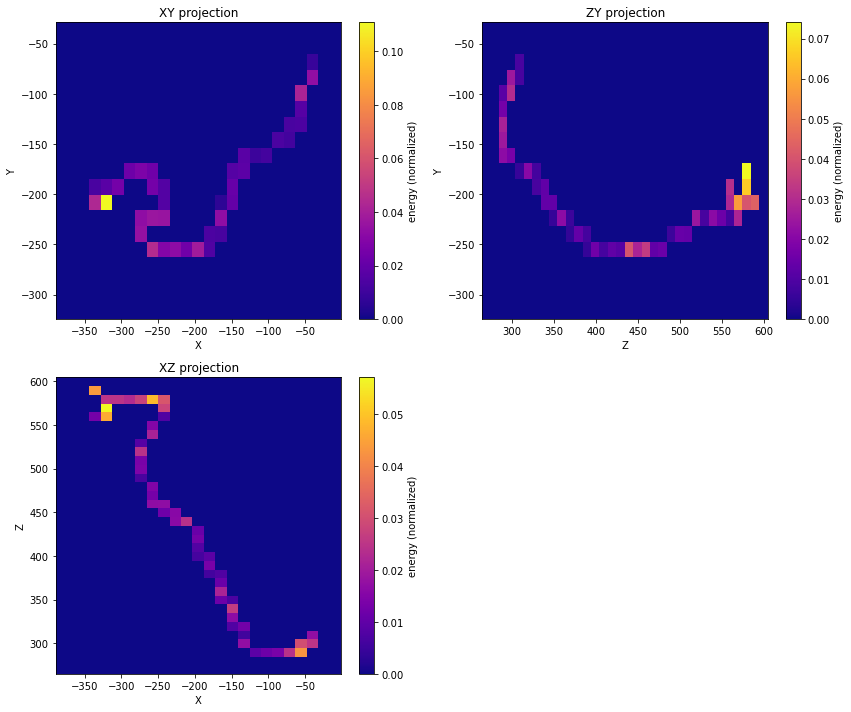

In [ ]:
#evtdeco   = evtfun.get_deconvoluted_data(evt)
evtdeco   = datadeco.groupby('dataset_id').get_group(ievent)
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
enedeco   = evtdeco.enecn.values
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);

In [94]:
print(f" total corrected and normalized energy of deco hits = ", evtdeco.enecn.sum(),
       "\n total corrected energy en slices with decho hits = ", evtdeco.enecc.sum(),
       "\n total original energy of the deco hits = ", evtdeco.energy.sum())

 total corrected and normalized energy of deco hits =  1.0000000000000004 
 total corrected energy en slices with decho hits =  0.9892529263161123 
 total original energy of the deco hits =  0.22453502


## Display graph

In [95]:
graph                      = graphfun.convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
componentes, longest_graph = graphfun.graph_connectivity(graph)
_, longest_graph2          = graphfun.graph_connectivity(longest_graph)

[(-1, -1, -1), (-1, -1, 0), (-1, -1, 1), (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), (-1, 1, -1), (-1, 1, 0), (-1, 1, 1), (0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (0, 0, 0), (0, 0, 1), (0, 1, -1), (0, 1, 0), (0, 1, 1), (1, -1, -1), (1, -1, 0), (1, -1, 1), (1, 0, -1), (1, 0, 0), (1, 0, 1), (1, 1, -1), (1, 1, 0), (1, 1, 1)]
Is graph conected?  True
Number of components: 1
Component 1: {(10, 4, 17), (13, 4, 13), (9, 8, 31), (9, 4, 19), (16, 9, 4), (19, 11, 2), (21, 13, 2), (8, 9, 31), (22, 15, 3), (16, 9, 5), (14, 7, 8), (10, 4, 18), (21, 12, 2), (16, 10, 3), (3, 8, 29), (7, 9, 31), (15, 9, 6), (13, 5, 11), (8, 6, 28), (7, 6, 26), (8, 4, 19), (15, 9, 5), (17, 10, 2), (15, 8, 6), (5, 8, 31), (7, 5, 24), (4, 8, 29), (15, 7, 7), (22, 16, 4), (15, 8, 7), (3, 7, 32), (4, 7, 30), (7, 6, 25), (9, 7, 31), (13, 5, 12), (14, 5, 10), (18, 10, 2), (6, 9, 31), (4, 7, 31), (14, 5, 11), (9, 6, 29), (7, 5, 23), (14, 6, 10), (8, 6, 27), (15, 7, 8), (20, 12, 2), (22, 15, 4), (9, 6, 30), (7, 5, 22), (12, 4

extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 8, 29)
extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 7, 32)


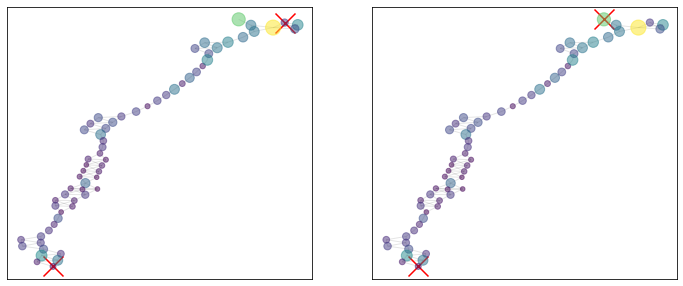

In [96]:
cv = pltext.canvas(2, 2)
cv(1)
u, v, dist = graphfun.graph_extremes(graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(graph, (u, v))
cv(2)
u, v, dist = graphfun.graph_extremes(longest_graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(longest_graph, (u, v))

In [40]:
graph.nodes

NodeView(((3, 7, 32), (4, 7, 31), (3, 8, 29), (4, 7, 29), (4, 7, 30), (4, 8, 29), (5, 8, 31), (6, 9, 31), (7, 9, 31), (7, 5, 22), (7, 5, 23), (8, 4, 21), (7, 5, 24), (7, 6, 25), (7, 6, 26), (8, 6, 27), (8, 8, 31), (8, 9, 31), (8, 4, 19), (8, 4, 20), (9, 4, 18), (9, 4, 19), (8, 6, 28), (9, 6, 29), (9, 7, 31), (9, 8, 31), (10, 4, 17), (10, 4, 18), (9, 6, 30), (11, 4, 17), (12, 4, 16), (12, 4, 13), (12, 4, 14), (13, 4, 12), (13, 4, 13), (13, 5, 12), (12, 4, 15), (13, 5, 11), (14, 5, 11), (14, 5, 10), (14, 6, 10), (14, 6, 9), (14, 6, 8), (14, 7, 8), (15, 7, 7), (15, 7, 8), (15, 8, 7), (15, 8, 6), (15, 9, 5), (15, 9, 6), (16, 9, 5), (16, 9, 4), (16, 10, 3), (17, 10, 2), (18, 10, 2), (19, 11, 2), (20, 11, 2), (20, 12, 2), (21, 12, 2), (21, 13, 2), (21, 14, 2), (21, 14, 3), (22, 15, 3), (22, 15, 4), (22, 16, 4)))